# Experiment: Reddit Comment-Only vs Context-Aware Sarcasm Detection

This notebook compares two Reddit input formulations under a shared evaluation pipeline:
- `comment_only`
- `context_aware`

Model families:
- `TF-IDF + Logistic Regression`
- `Bidirectional LSTM`
- custom encoder-only `Transformer`

The split, preprocessing rules, and sampled row ids are fixed so that only the input formulation changes across the two modes.


## 1. Setup

This notebook is written to run in either:

- local Jupyter inside the repository
- Google Colab with the project folder synced into Drive

Recommended runtime:

- CPU is fine for data loading and TF-IDF
- GPU is strongly recommended for the BiLSTM and Transformer sections


In [1]:
%pip install -q numpy pandas scikit-learn matplotlib seaborn torch


In [2]:
# Path configuration for local Jupyter or Google Colab.
from pathlib import Path

try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore

    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

RUN_CONTEXT = "auto"  # one of: "auto", "local", "colab_drive"
MANUAL_PROJECT_ROOT = None
MANUAL_REDDIT_TRAIN_PATH = None

REDDIT_TRAIN_RELATIVE_CANDIDATES = [
    Path("Dataset") / "Reddit" / "train-balanced-sarcasm.csv",
    Path("Dataset") / "Reddit" / "train-balanced-sarc.csv.gz",
    Path("Dataset") / "Reddit" / "train-balanced-sarc.csv" / "train-balanced-sarc.csv",
]


def mount_drive_if_needed() -> None:
    if IN_COLAB and drive is not None and RUN_CONTEXT in {"auto", "colab_drive"}:
        drive.mount("/content/drive", force_remount=False)


def unique_paths(paths) -> list[Path]:
    seen = set()
    result = []
    for path in paths:
        if path is None:
            continue
        candidate = Path(path).expanduser()
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            result.append(candidate)
    return result


def find_reddit_train_under_root(project_root: Path | None) -> Path | None:
    if project_root is None:
        return None
    root = Path(project_root).expanduser()
    for relative_path in REDDIT_TRAIN_RELATIVE_CANDIDATES:
        candidate = root / relative_path
        if candidate.exists():
            return candidate.resolve()
    return None


def resolve_project_root_from_train_path(train_path: Path | None) -> Path | None:
    if train_path is None:
        return None
    resolved_train_path = Path(train_path).expanduser().resolve()
    for parent in unique_paths([resolved_train_path.parent, *resolved_train_path.parents]):
        matched_train_path = find_reddit_train_under_root(parent)
        if matched_train_path is not None and matched_train_path.resolve() == resolved_train_path:
            return parent.resolve()
    return None


def discover_project_root() -> Path | None:
    direct_root = resolve_project_root_from_train_path(find_reddit_train_under_root(MANUAL_PROJECT_ROOT))
    if direct_root is not None:
        return direct_root

    direct_from_train = resolve_project_root_from_train_path(MANUAL_REDDIT_TRAIN_PATH)
    if direct_from_train is not None:
        return direct_from_train

    candidate_roots = [Path.cwd(), *Path.cwd().parents]
    if IN_COLAB and RUN_CONTEXT in {"auto", "colab_drive"}:
        candidate_roots.extend(
            [
                Path("/content"),
                Path("/content/drive"),
                Path("/content/drive/MyDrive"),
            ]
        )
    else:
        candidate_roots.extend(
            [
                Path.home(),
                Path.home() / "Documents",
                Path.home() / "Downloads",
            ]
        )

    for candidate_root in unique_paths(candidate_roots):
        matched_train_path = find_reddit_train_under_root(candidate_root)
        if matched_train_path is not None:
            return candidate_root.resolve()

    search_roots = [Path.cwd(), *Path.cwd().parents]
    if IN_COLAB:
        search_roots.extend([Path("/content"), Path("/content/drive"), Path("/content/drive/MyDrive")])
    else:
        search_roots.extend([Path.home(), Path.home() / "Documents", Path.home() / "Downloads"])

    for search_root in unique_paths(search_roots):
        if not search_root.exists():
            continue
        try:
            for pattern in ("train-balanced-sarcasm.csv", "train-balanced-sarc.csv.gz", "train-balanced-sarc.csv"):
                for match in search_root.rglob(pattern):
                    resolved_root = resolve_project_root_from_train_path(match)
                    if resolved_root is not None:
                        return resolved_root
        except (OSError, PermissionError):
            continue
    return None


mount_drive_if_needed()
PROJECT_ROOT = discover_project_root()

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root automatically. Set MANUAL_PROJECT_ROOT to the repository root "
        "or MANUAL_REDDIT_TRAIN_PATH to a Reddit training file, then rerun this cell. "
        f"Current working directory: {Path.cwd()}"
    )

REDDIT_TRAIN_PATH = find_reddit_train_under_root(PROJECT_ROOT)
if REDDIT_TRAIN_PATH is None:
    raise FileNotFoundError(
        "A Reddit training file was not found under Dataset/Reddit/. "
        "Supported names are train-balanced-sarcasm.csv, train-balanced-sarc.csv.gz, "
        "and train-balanced-sarc.csv/train-balanced-sarc.csv."
    )

UNUSED_REDDIT_TEST_PATHS = [
    PROJECT_ROOT / "Dataset" / "Reddit" / "test-balanced.csv",
    PROJECT_ROOT / "Dataset" / "Reddit" / "test-unbalanced.csv",
]
OUTPUT_ROOT = PROJECT_ROOT / "Notebooks" / "jupyter-notebook"
NOTEBOOK_OUTPUT_PATH = OUTPUT_ROOT / "reddit-sarcasm-comment-vs-context-colab.ipynb"

print(f"Project root: {PROJECT_ROOT}")
print(f"Reddit training source: {REDDIT_TRAIN_PATH}")
print("Optional Reddit test files:")
for test_path in UNUSED_REDDIT_TEST_PATHS:
    print(f"  - {test_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project
Reddit training source: /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Dataset/Reddit/train-balanced-sarcasm.csv
This notebook intentionally ignores the provided Reddit test CSV files:
  - /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Dataset/Reddit/test-balanced.csv
  - /content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Dataset/Reddit/test-unbalanced.csv


In [3]:
# Imports, reproducibility, and experiment configuration
from __future__ import annotations

import copy
import html
import math
import random
import re
import unicodedata
import warnings
from collections import Counter
from textwrap import dedent

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

LABEL_NAMES = {0: "not_sarcastic", 1: "sarcastic"}
MODE_ORDER = ["comment_only", "context_aware"]
MODEL_ORDER = [
    "TF-IDF + Logistic Regression",
    "Bidirectional LSTM",
    "Encoder-only Transformer",
]
MODE_SETTINGS = {
    "comment_only": {
        "max_length_cap": 64,
        "max_length_floor": 8,
    },
    "context_aware": {
        "max_length_cap": 96,
        "max_length_floor": 16,
    },
}
CONFIG = {
    "seed": SEED,
    "sample_train_size": 200_000,
    "sample_validation_size": 20_000,
    "sample_test_size": 20_000,
    "tfidf_max_features": 50_000,
    "max_vocab_size": 30_000,
    "min_token_frequency": 2,
    "batch_size": 128,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "lstm_layers": 1,
    "transformer_layers": 2,
    "transformer_heads": 4,
    "transformer_ff_dim": 256,
    "dropout": 0.25,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 6,
    "early_stopping_patience": 2,
    "gradient_clip": 1.0,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_colwidth", 220)
print(f"Using device: {DEVICE}")
display(Markdown("### Active configuration"))
pd.DataFrame([CONFIG]).T.rename(columns={0: "value"})


Using device: cuda


### Active configuration

,value
seed,7.0000
sample_train_size,200000.0000
sample_validation_size,20000.0000
sample_test_size,20000.0000
tfidf_max_features,50000.0000
max_vocab_size,30000.0000
min_token_frequency,2.0000
batch_size,128.0000
embedding_dim,128.0000
hidden_dim,128.0000


## 2. Benchmark Position

Reddit is the primary benchmark for the project because it is harder than hashtag-driven Twitch data and because parent comments make the context question explicit.


## 3. Data Loading And Cleaning

We load the Reddit training CSV directly and enforce the agreed cleaning rules:

- keep only `label`, `comment`, `parent_comment`, `subreddit`, and `score`
- drop rows with empty `comment` text
- remove exact duplicate `(label, comment, parent_comment)` rows before sampling
- preserve the full `parent_comment` text without truncating it at load time


In [4]:
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
USER_PATTERN = re.compile(r"(?<!\w)(?:/?u/\w+|@\w+)")
WHITESPACE_PATTERN = re.compile(r"\s+")
TOKEN_PATTERN = re.compile(
    r"<sep>|<url>|<user>|[a-z0-9]+(?:'[a-z0-9]+)?|[!?.,;:()\[\]{}\"`-]+"
)


def normalize_text(text: str) -> str:
    """Normalize text while preserving punctuation and discourse markers."""
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""

    cleaned = str(text)
    for _ in range(2):
        cleaned = html.unescape(cleaned)
    cleaned = unicodedata.normalize("NFKC", cleaned)
    cleaned = cleaned.lower()
    cleaned = URL_PATTERN.sub(" <url> ", cleaned)
    cleaned = USER_PATTERN.sub(" <user> ", cleaned)
    cleaned = WHITESPACE_PATTERN.sub(" ", cleaned).strip()
    return cleaned


def load_reddit_data(csv_path: Path) -> tuple[pd.DataFrame, dict]:
    """Load the Reddit CSV with the cleaning rules required for this notebook."""
    use_columns = ["label", "comment", "parent_comment", "subreddit", "score"]
    raw_df = pd.read_csv(csv_path, usecols=use_columns, low_memory=False)
    raw_df = raw_df.reset_index().rename(columns={"index": "source_row_id"})

    raw_df["label"] = raw_df["label"].astype(int)
    for column in ["comment", "parent_comment", "subreddit"]:
        raw_df[column] = raw_df[column].fillna("").astype(str)
    raw_df["score"] = pd.to_numeric(raw_df["score"], errors="coerce").fillna(0.0)

    initial_rows = len(raw_df)
    nonempty_mask = raw_df["comment"].str.strip().ne("")
    empty_comment_rows_removed = int((~nonempty_mask).sum())

    cleaned_df = raw_df.loc[
        nonempty_mask,
        ["source_row_id", "label", "comment", "parent_comment", "subreddit", "score"],
    ].copy()
    before_dedup_rows = len(cleaned_df)
    cleaned_df = cleaned_df.drop_duplicates(
        subset=["label", "comment", "parent_comment"],
        keep="first",
    ).copy()
    duplicate_rows_removed = before_dedup_rows - len(cleaned_df)

    cleaned_df["row_id"] = np.arange(len(cleaned_df), dtype=np.int64)
    cleaned_df["label_name"] = cleaned_df["label"].map(LABEL_NAMES)

    report = {
        "source_csv": str(csv_path),
        "initial_rows": initial_rows,
        "empty_comment_rows_removed": empty_comment_rows_removed,
        "duplicate_rows_removed": duplicate_rows_removed,
        "rows_after_cleaning": len(cleaned_df),
        "label_0_rows": int((cleaned_df["label"] == 0).sum()),
        "label_1_rows": int((cleaned_df["label"] == 1).sum()),
    }
    return cleaned_df.reset_index(drop=True), report


In [5]:
reddit_df, cleaning_report = load_reddit_data(REDDIT_TRAIN_PATH)

cleaning_summary_df = pd.DataFrame([cleaning_report]).T.rename(columns={0: "value"})
display(cleaning_summary_df)
display(
    reddit_df[
        ["row_id", "source_row_id", "label_name", "subreddit", "score", "comment", "parent_comment"]
    ].head(3)
)

required_rows = (
    CONFIG["sample_train_size"]
    + CONFIG["sample_validation_size"]
    + CONFIG["sample_test_size"]
)
assert cleaning_report["empty_comment_rows_removed"] >= 1, "Expected empty comments to be removed."
assert cleaning_report["duplicate_rows_removed"] >= 1, "Expected duplicate rows to be removed."
assert len(reddit_df) >= required_rows, "Not enough cleaned Reddit rows for the planned sample sizes."


,value
source_csv,/content/drive/MyDrive/UNI/AdvancedMachineLearning/Project/Dataset/Reddit/train-balanced-sarcasm.csv
initial_rows,1010826
empty_comment_rows_removed,55
duplicate_rows_removed,802
rows_after_cleaning,1009969
label_0_rows,504910
label_1_rows,505059


,row_id,source_row_id,label_name,subreddit,score,comment,parent_comment
0,0,0,not_sarcastic,politics,2,NC and NH.,"Yeah, I get that argument. At this point, I'd prefer is she lived in NC as well."
1,1,1,not_sarcastic,nba,-4,You do know west teams play against west teams more than east teams right?,The blazers and Mavericks (The wests 5 and 6 seed) did not even carry a good enough record to make the playoffs in the east last year.
2,2,2,not_sarcastic,nfl,3,"They were underdogs earlier today, but since Gronk's announcement this afternoon, the Vegas line has moved to patriots -1",They're favored to win.


## 4. Fixed Sample Split Construction

A single stratified sample is reused across both text modes:
- `200k / 20k / 20k` for train / validation / test
- `seed = 7`
- identical row ids across both modes


In [6]:
def build_reddit_sample_split(
    cleaned_df: pd.DataFrame,
    train_size: int = 200_000,
    validation_size: int = 20_000,
    test_size: int = 20_000,
    seed: int = 7,
) -> tuple[dict[str, pd.DataFrame], dict[str, np.ndarray], np.ndarray, pd.DataFrame]:
    """Create one fixed Reddit sample split that can be reused across modes."""
    required_total = train_size + validation_size + test_size
    if len(cleaned_df) < required_total:
        raise ValueError(
            f"Need at least {required_total:,} cleaned rows, found {len(cleaned_df):,}."
        )

    sampled_row_ids, _ = train_test_split(
        cleaned_df["row_id"],
        train_size=required_total,
        stratify=cleaned_df["label"],
        random_state=seed,
    )
    sampled_row_ids = np.sort(np.asarray(sampled_row_ids))

    indexed_df = cleaned_df.set_index("row_id")
    sampled_df = indexed_df.loc[sampled_row_ids].reset_index()

    train_row_ids, holdout_row_ids = train_test_split(
        sampled_df["row_id"],
        train_size=train_size,
        stratify=sampled_df["label"],
        random_state=seed,
    )
    train_row_ids = np.sort(np.asarray(train_row_ids))
    holdout_row_ids = np.sort(np.asarray(holdout_row_ids))
    holdout_df = indexed_df.loc[holdout_row_ids].reset_index()

    validation_row_ids, test_row_ids = train_test_split(
        holdout_df["row_id"],
        train_size=validation_size,
        test_size=test_size,
        stratify=holdout_df["label"],
        random_state=seed,
    )
    split_row_ids = {
        "train": train_row_ids,
        "validation": np.sort(np.asarray(validation_row_ids)),
        "test": np.sort(np.asarray(test_row_ids)),
    }

    split_frames = {}
    summary_rows = []
    for split_name, row_ids in split_row_ids.items():
        frame = indexed_df.loc[row_ids].reset_index().copy()
        split_frames[split_name] = frame
        summary_rows.append(
            {
                "split": split_name,
                "rows": len(frame),
                "sarcastic_share": frame["label"].mean(),
                "label_0_rows": int((frame["label"] == 0).sum()),
                "label_1_rows": int((frame["label"] == 1).sum()),
                "row_id_min": int(frame["row_id"].min()),
                "row_id_max": int(frame["row_id"].max()),
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    return split_frames, split_row_ids, sampled_row_ids, summary_df


In [7]:
sample_splits, split_row_ids, sampled_row_ids, split_summary_df = build_reddit_sample_split(
    reddit_df,
    train_size=CONFIG["sample_train_size"],
    validation_size=CONFIG["sample_validation_size"],
    test_size=CONFIG["sample_test_size"],
    seed=SEED,
)

display(split_summary_df)

assert len(sample_splits["train"]) == 200_000
assert len(sample_splits["validation"]) == 20_000
assert len(sample_splits["test"]) == 20_000
assert len(sampled_row_ids) == 240_000
assert len(np.unique(sampled_row_ids)) == 240_000
assert set(split_row_ids["train"]).isdisjoint(split_row_ids["validation"])
assert set(split_row_ids["train"]).isdisjoint(split_row_ids["test"])
assert set(split_row_ids["validation"]).isdisjoint(split_row_ids["test"])


,split,rows,sarcastic_share,label_0_rows,label_1_rows,row_id_min,row_id_max
0,train,200000,0.500075,99985,100015,9,1009967
1,validation,20000,0.500100,9998,10002,59,1009950
2,test,20000,0.500050,9999,10001,6,1009952


## 5. Comment-Only Vs Context-Aware Text Setup

The two modes differ only in how we build the model input text:

- `comment_only`: normalized `comment`
- `context_aware`: normalized `parent_comment + " <sep> " + comment`

The separator is a literal token, and the downstream vocabularies are built from each mode's training text only.


In [8]:
def tokenize_text(text: str) -> list[str]:
    """Tokenize normalized text while preserving special placeholders and punctuation."""
    if not text:
        return []
    return TOKEN_PATTERN.findall(text)


def prepare_mode_frame(frame: pd.DataFrame, mode: str) -> pd.DataFrame:
    """Create the mode-specific text view without changing the sampled row ids."""
    prepared = frame[
        ["row_id", "source_row_id", "label", "label_name", "comment", "parent_comment", "subreddit", "score"]
    ].copy()
    prepared["comment_normalized"] = prepared["comment"].map(normalize_text)
    prepared["parent_comment_normalized"] = prepared["parent_comment"].map(normalize_text)

    if mode == "comment_only":
        prepared["model_text"] = prepared["comment_normalized"]
    elif mode == "context_aware":
        prepared["model_text"] = (
            prepared["parent_comment_normalized"].str.strip()
            + " <sep> "
            + prepared["comment_normalized"].str.strip()
        ).str.replace(r"\s+", " ", regex=True).str.strip()
    else:
        raise ValueError(f"Unknown mode: {mode}")

    prepared["mode"] = mode
    prepared["token_count"] = prepared["model_text"].map(lambda value: len(tokenize_text(value)))
    return prepared


def compute_mode_max_length(train_frame: pd.DataFrame, mode: str) -> tuple[int, int]:
    """Compute p95 token length and the capped, mode-specific max length."""
    p95_train_tokens = int(np.ceil(train_frame["token_count"].quantile(0.95)))
    settings = MODE_SETTINGS[mode]
    max_length = max(
        settings["max_length_floor"],
        min(settings["max_length_cap"], max(1, p95_train_tokens)),
    )
    return p95_train_tokens, max_length


In [9]:
mode_split_frames = {
    mode_name: {
        split_name: prepare_mode_frame(split_frame, mode_name)
        for split_name, split_frame in sample_splits.items()
    }
    for mode_name in MODE_ORDER
}

for split_name in ["train", "validation", "test"]:
    comment_ids = mode_split_frames["comment_only"][split_name]["row_id"].to_numpy()
    context_ids = mode_split_frames["context_aware"][split_name]["row_id"].to_numpy()
    assert np.array_equal(comment_ids, context_ids), f"Row ids diverged for {split_name}."
    assert not mode_split_frames["comment_only"][split_name]["model_text"].str.contains(
        "<sep>", regex=False
    ).any()
    assert mode_split_frames["context_aware"][split_name]["model_text"].str.contains(
        "<sep>", regex=False
    ).all()
    assert mode_split_frames["context_aware"][split_name]["model_text"].map(
        lambda value: "<sep>" in tokenize_text(value)
    ).all()

mode_summary_rows = []
mode_sequence_plan_rows = []
for mode_name in MODE_ORDER:
    p95_train_tokens, derived_max_length = compute_mode_max_length(
        mode_split_frames[mode_name]["train"],
        mode_name,
    )
    mode_sequence_plan_rows.append(
        {
            "mode": mode_name,
            "p95_train_tokens": p95_train_tokens,
            "derived_max_length": derived_max_length,
            "sep_expected": mode_name == "context_aware",
        }
    )
    for split_name, split_frame in mode_split_frames[mode_name].items():
        mode_summary_rows.append(
            {
                "mode": mode_name,
                "split": split_name,
                "rows": len(split_frame),
                "sarcastic_share": split_frame["label"].mean(),
                "avg_token_count": split_frame["token_count"].mean(),
                "p95_token_count": split_frame["token_count"].quantile(0.95),
            }
        )

mode_summary_df = pd.DataFrame(mode_summary_rows)
mode_sequence_plan_df = pd.DataFrame(mode_sequence_plan_rows)
MODE_SEQUENCE_PLAN = mode_sequence_plan_df.set_index("mode").to_dict(orient="index")

display(mode_sequence_plan_df)
display(mode_summary_df)
display(
    mode_split_frames["context_aware"]["train"][
        ["row_id", "subreddit", "comment", "parent_comment", "model_text"]
    ].head(3)
)


,mode,p95_train_tokens,derived_max_length,sep_expected
0,comment_only,28,28,False
1,context_aware,105,96,True


,mode,split,rows,sarcastic_share,avg_token_count,p95_token_count
0,comment_only,train,200000,0.500075,11.841345,28.0
1,comment_only,validation,20000,0.500100,11.795150,27.0
2,comment_only,test,20000,0.500050,11.842950,28.0
3,context_aware,train,200000,0.500075,40.565845,105.0
4,context_aware,validation,20000,0.500100,40.165850,103.0
5,context_aware,test,20000,0.500050,40.762800,106.0


,row_id,subreddit,comment,parent_comment,model_text
0,9,Lollapalooza,I would love to see him at lolla.,"Probably count Kanye out Since the rest of his tour is canceled, it doesn't seem in the cards. But he's also so unpredictable, it could change. Thankfully I saw him before he started canceling shows, going on long ra...","probably count kanye out since the rest of his tour is canceled, it doesn't seem in the cards. but he's also so unpredictable, it could change. thankfully i saw him before he started canceling shows, going on long ra..."
1,11,baseball,Damn I was hoping God was real,James Shields Will Not Exercise Opt-Out Clause,james shields will not exercise opt-out clause <sep> damn i was hoping god was real
2,12,exmormon,They have an agenda.,There's no time to worry about leaks when they gays are already out to get you.,there's no time to worry about leaks when they gays are already out to get you. <sep> they have an agenda.


## 6. TF-IDF Experiments

The lexical baseline uses unigram and bigram TF-IDF features with `max_features = 50000`. To stay faithful to the notebook's text normalization choices, it uses the same tokenizer as the neural models instead of letting punctuation disappear through the default scikit-learn token pattern.


In [10]:
def compute_classification_metrics(y_true, y_pred) -> dict[str, float]:
    """Compute standard binary classification metrics."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def show_confusion_matrix(y_true, y_pred, title: str, ax=None):
    """Visualize a confusion matrix using seaborn."""
    matrix = confusion_matrix(y_true, y_pred)
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    return ax


def collect_error_cases(
    frame: pd.DataFrame,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    model_name: str,
    mode_name: str,
    top_n: int = 6,
) -> pd.DataFrame:
    """Collect the most confident false positives and false negatives."""
    analysis_df = frame[
        [
            "row_id",
            "subreddit",
            "score",
            "comment",
            "parent_comment",
            "model_text",
            "label",
            "label_name",
        ]
    ].copy()
    analysis_df["predicted_label"] = predictions.astype(int)
    analysis_df["predicted_label_name"] = analysis_df["predicted_label"].map(LABEL_NAMES)
    analysis_df["predicted_probability"] = probabilities
    analysis_df["confidence"] = np.where(
        analysis_df["predicted_label"] == 1,
        analysis_df["predicted_probability"],
        1.0 - analysis_df["predicted_probability"],
    )
    errors = analysis_df[analysis_df["predicted_label"] != analysis_df["label"]].copy()
    errors["model"] = model_name
    errors["mode"] = mode_name
    errors["error_type"] = np.where(
        (errors["label"] == 0) & (errors["predicted_label"] == 1),
        "false_positive",
        "false_negative",
    )

    top_false_positives = (
        errors[errors["error_type"] == "false_positive"]
        .sort_values("confidence", ascending=False)
        .head(top_n)
    )
    top_false_negatives = (
        errors[errors["error_type"] == "false_negative"]
        .sort_values("confidence", ascending=False)
        .head(top_n)
    )
    return pd.concat([top_false_positives, top_false_negatives], ignore_index=True)


def run_tfidf_experiment(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    mode_name: str,
) -> dict:
    """Fit and evaluate the TF-IDF baseline on one Reddit text mode."""
    baseline_model = Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    tokenizer=tokenize_text,
                    preprocessor=None,
                    token_pattern=None,
                    lowercase=False,
                    ngram_range=(1, 2),
                    max_features=CONFIG["tfidf_max_features"],
                    min_df=2,
                    sublinear_tf=True,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=SEED,
                ),
            ),
        ]
    )

    baseline_model.fit(train_frame["model_text"], train_frame["label"])

    results = []
    predictions = {}
    probabilities = {}
    for split_name, frame in {"validation": val_frame, "test": test_frame}.items():
        split_probabilities = baseline_model.predict_proba(frame["model_text"])[:, 1]
        split_predictions = (split_probabilities >= 0.5).astype(int)
        metrics = compute_classification_metrics(frame["label"], split_predictions)
        metrics.update(
            {
                "mode": mode_name,
                "model": "TF-IDF + Logistic Regression",
                "split": split_name,
            }
        )
        results.append(metrics)
        predictions[split_name] = split_predictions
        probabilities[split_name] = split_probabilities

    return {
        "results": results,
        "predictions": predictions,
        "probabilities": probabilities,
    }


## 7. BiLSTM Experiments

The recurrent model keeps the same high-level design as the earlier notebooks:

- learned embeddings
- bidirectional LSTM encoder
- final-state aggregation from the forward and backward directions
- dropout before the classification head


In [11]:
def build_vocab(
    texts: pd.Series,
    min_token_frequency: int = 2,
    max_vocab_size: int | None = None,
) -> tuple[dict[str, int], Counter]:
    """Build a vocabulary from training text only."""
    counter = Counter()
    for text in texts:
        counter.update(tokenize_text(text))

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, count in counter.most_common():
        if count < min_token_frequency:
            continue
        if max_vocab_size is not None and len(vocab) >= max_vocab_size:
            break
        vocab[token] = len(vocab)
    return vocab, counter


def encode_and_pad(
    texts: pd.Series,
    vocab: dict[str, int],
    max_length: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert normalized text into padded token-id arrays."""
    sequences = []
    lengths = []
    unk_idx = vocab["<unk>"]
    pad_idx = vocab["<pad>"]

    for text in texts:
        token_ids = [vocab.get(token, unk_idx) for token in tokenize_text(text)]
        token_ids = token_ids[:max_length]
        effective_length = max(1, len(token_ids))
        if not token_ids:
            token_ids = [unk_idx]
        padded = token_ids + [pad_idx] * (max_length - len(token_ids))
        sequences.append(padded[:max_length])
        lengths.append(min(effective_length, max_length))

    return np.asarray(sequences, dtype=np.int64), np.asarray(lengths, dtype=np.int64)


class TextClassificationDataset(Dataset):
    """Fixed-length text classification dataset."""

    def __init__(self, input_ids: np.ndarray, lengths: np.ndarray, labels: np.ndarray):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        return self.input_ids[idx], self.lengths[idx], self.labels[idx]


def prepare_sequence_bundle(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    mode_name: str,
) -> dict:
    """Build mode-specific vocabulary, lengths, and dataloaders from train text only."""
    p95_train_tokens, max_length = compute_mode_max_length(train_frame, mode_name)
    vocab, token_counter = build_vocab(
        train_frame["model_text"],
        min_token_frequency=CONFIG["min_token_frequency"],
        max_vocab_size=CONFIG["max_vocab_size"],
    )

    if mode_name == "context_aware":
        assert "<sep>" in vocab, "Expected <sep> in the context-aware training vocabulary."
    else:
        assert "<sep>" not in vocab, "Unexpected <sep> token in comment-only vocabulary."

    def make_dataset(frame: pd.DataFrame) -> TextClassificationDataset:
        input_ids, lengths = encode_and_pad(frame["model_text"], vocab, max_length)
        labels = frame["label"].to_numpy(dtype=np.float32)
        return TextClassificationDataset(input_ids, lengths, labels)

    train_dataset = make_dataset(train_frame)
    val_dataset = make_dataset(val_frame)
    test_dataset = make_dataset(test_frame)

    return {
        "vocab": vocab,
        "token_counter": token_counter,
        "p95_train_tokens": p95_train_tokens,
        "max_length": max_length,
        "pad_idx": vocab["<pad>"],
        "train_loader": DataLoader(
            train_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=True,
        ),
        "val_loader": DataLoader(
            val_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
        ),
        "test_loader": DataLoader(
            test_dataset,
            batch_size=CONFIG["batch_size"],
            shuffle=False,
        ),
    }


def run_epoch(model, dataloader, criterion, optimizer=None):
    """Run one epoch and return loss, probabilities, predictions, and labels."""
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    all_probabilities = []
    all_predictions = []
    all_labels = []

    for input_ids, lengths, labels in dataloader:
        input_ids = input_ids.to(DEVICE)
        lengths = lengths.to(DEVICE)
        labels = labels.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["gradient_clip"])
                optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).long()

        total_loss += loss.item() * labels.size(0)
        all_probabilities.append(probabilities.detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    y_prob = np.concatenate(all_probabilities)
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels).astype(int)
    metrics = compute_classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / len(dataloader.dataset)
    return metrics, y_prob, y_pred, y_true


def train_neural_model(model, train_loader, val_loader, model_name: str, mode_name: str):
    """Train a neural model with AdamW and validation-F1 early stopping."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    best_state = None
    best_val_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, CONFIG["epochs"] + 1):
        train_metrics, *_ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics, *_ = run_epoch(model, val_loader, criterion, optimizer=None)

        history.append(
            {
                "mode": mode_name,
                "model": model_name,
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_f1": train_metrics["f1"],
                "val_loss": val_metrics["loss"],
                "val_f1": val_metrics["f1"],
                "val_accuracy": val_metrics["accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
            }
        )

        print(
            f"{mode_name} | {model_name} | epoch {epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | train_f1={train_metrics['f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
            print(f"Early stopping triggered for {mode_name} | {model_name}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def evaluate_neural_model(model, dataloader, split_name: str, model_name: str, mode_name: str):
    """Evaluate a trained neural model on one split."""
    criterion = nn.BCEWithLogitsLoss()
    metrics, probabilities, predictions, labels = run_epoch(
        model,
        dataloader,
        criterion,
        optimizer=None,
    )
    metrics.update({"mode": mode_name, "model": model_name, "split": split_name})
    return metrics, probabilities, predictions, labels


class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM text classifier with final-state aggregation."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.encoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden_state, _) = self.encoder(packed)
        forward_hidden = hidden_state[-2]
        backward_hidden = hidden_state[-1]
        features = torch.cat([forward_hidden, backward_hidden], dim=1)
        logits = self.classifier(self.dropout(features)).squeeze(-1)
        return logits


## 8. Transformer Experiments

The Transformer remains encoder-only and custom-built in PyTorch, following the same lecture-style direction as the earlier project notebooks. It uses:

- learned token embeddings
- sinusoidal positional encoding
- stacked encoder layers
- mean pooling over non-padding tokens


In [12]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""

    def __init__(self, embedding_dim: int, max_length: int):
        super().__init__()
        positions = torch.arange(max_length).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2) * (-math.log(10000.0) / embedding_dim)
        )
        pe = torch.zeros(max_length, embedding_dim)
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return inputs + self.pe[:, : inputs.size(1)]


class TransformerEncoderClassifier(nn.Module):
    """Encoder-only Transformer text classifier."""

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_heads: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        pad_idx: int,
        max_length: int,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.position = PositionalEncoding(embedding_dim, max_length)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embedding_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        padding_mask = input_ids.eq(self.pad_idx)
        embeddings = self.embedding(input_ids) * math.sqrt(self.embedding_dim)
        encoded = self.position(embeddings)
        encoded = self.encoder(encoded, src_key_padding_mask=padding_mask)

        valid_mask = (~padding_mask).unsqueeze(-1)
        pooled = (encoded * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1)
        logits = self.classifier(self.dropout(pooled)).squeeze(-1)
        return logits


def run_neural_experiment(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    mode_name: str,
    model_name: str,
    model_factory,
) -> dict:
    """Train and evaluate one neural model on one Reddit mode."""
    sequence_bundle = prepare_sequence_bundle(train_frame, val_frame, test_frame, mode_name)
    model = model_factory(sequence_bundle).to(DEVICE)
    model, history_df = train_neural_model(
        model,
        sequence_bundle["train_loader"],
        sequence_bundle["val_loader"],
        model_name=model_name,
        mode_name=mode_name,
    )

    results = []
    predictions = {}
    probabilities = {}
    for split_name, loader in {
        "validation": sequence_bundle["val_loader"],
        "test": sequence_bundle["test_loader"],
    }.items():
        metrics, split_probabilities, split_predictions, _ = evaluate_neural_model(
            model,
            loader,
            split_name=split_name,
            model_name=model_name,
            mode_name=mode_name,
        )
        results.append(metrics)
        predictions[split_name] = split_predictions
        probabilities[split_name] = split_probabilities

    return {
        "results": results,
        "predictions": predictions,
        "probabilities": probabilities,
        "history_df": history_df,
        "sequence_bundle": {
            "vocab_size": len(sequence_bundle["vocab"]),
            "p95_train_tokens": sequence_bundle["p95_train_tokens"],
            "max_length": sequence_bundle["max_length"],
            "top_tokens": sequence_bundle["token_counter"].most_common(12),
        },
    }


def run_mode_suite(mode_name: str) -> tuple[list[dict], dict]:
    """Run all three models on one Reddit text mode."""
    train_frame = mode_split_frames[mode_name]["train"]
    val_frame = mode_split_frames[mode_name]["validation"]
    test_frame = mode_split_frames[mode_name]["test"]

    tfidf_artifact = run_tfidf_experiment(train_frame, val_frame, test_frame, mode_name)

    bilstm_artifact = run_neural_experiment(
        train_frame,
        val_frame,
        test_frame,
        mode_name=mode_name,
        model_name="Bidirectional LSTM",
        model_factory=lambda bundle: BiLSTMClassifier(
            vocab_size=len(bundle["vocab"]),
            embedding_dim=CONFIG["embedding_dim"],
            hidden_dim=CONFIG["hidden_dim"],
            num_layers=CONFIG["lstm_layers"],
            dropout=CONFIG["dropout"],
            pad_idx=bundle["pad_idx"],
        ),
    )

    transformer_artifact = run_neural_experiment(
        train_frame,
        val_frame,
        test_frame,
        mode_name=mode_name,
        model_name="Encoder-only Transformer",
        model_factory=lambda bundle: TransformerEncoderClassifier(
            vocab_size=len(bundle["vocab"]),
            embedding_dim=CONFIG["embedding_dim"],
            num_heads=CONFIG["transformer_heads"],
            num_layers=CONFIG["transformer_layers"],
            ff_dim=CONFIG["transformer_ff_dim"],
            dropout=CONFIG["dropout"],
            pad_idx=bundle["pad_idx"],
            max_length=bundle["max_length"],
        ),
    )

    all_results = (
        tfidf_artifact["results"]
        + bilstm_artifact["results"]
        + transformer_artifact["results"]
    )
    artifact = {
        "frames": {
            "train": train_frame,
            "validation": val_frame,
            "test": test_frame,
        },
        "models": {
            "TF-IDF + Logistic Regression": tfidf_artifact,
            "Bidirectional LSTM": bilstm_artifact,
            "Encoder-only Transformer": transformer_artifact,
        },
    }
    return all_results, artifact


In [13]:
all_results_records = []
mode_artifacts = {}

for mode_name in MODE_ORDER:
    print(f"\nRunning Reddit mode: {mode_name}")
    mode_results, mode_artifact = run_mode_suite(mode_name)
    all_results_records.extend(mode_results)
    mode_artifacts[mode_name] = mode_artifact

results_df = pd.DataFrame(all_results_records)
display(results_df)



Running Reddit mode: comment_only
comment_only | Bidirectional LSTM | epoch 01 | train_loss=0.5823 | train_f1=0.6699 | val_loss=0.5560 | val_f1=0.7049
comment_only | Bidirectional LSTM | epoch 02 | train_loss=0.5224 | train_f1=0.7264 | val_loss=0.5461 | val_f1=0.7117
comment_only | Bidirectional LSTM | epoch 03 | train_loss=0.4737 | train_f1=0.7650 | val_loss=0.5546 | val_f1=0.7207
comment_only | Bidirectional LSTM | epoch 04 | train_loss=0.4146 | train_f1=0.8050 | val_loss=0.5896 | val_f1=0.7074
comment_only | Bidirectional LSTM | epoch 05 | train_loss=0.3444 | train_f1=0.8453 | val_loss=0.6452 | val_f1=0.6932
Early stopping triggered for comment_only | Bidirectional LSTM.
comment_only | Encoder-only Transformer | epoch 01 | train_loss=0.6440 | train_f1=0.6297 | val_loss=0.5888 | val_f1=0.6875
comment_only | Encoder-only Transformer | epoch 02 | train_loss=0.5739 | train_f1=0.6885 | val_loss=0.5715 | val_f1=0.6877
comment_only | Encoder-only Transformer | epoch 03 | train_loss=0.5412

,accuracy,precision,recall,f1,mode,model,split,loss
0,0.71900,0.730050,0.695161,0.712179,comment_only,TF-IDF + Logistic Regression,validation,NaN
1,0.72145,0.731501,0.699830,0.715315,comment_only,TF-IDF + Logistic Regression,test,NaN
2,0.72325,0.727606,0.713857,0.720666,comment_only,Bidirectional LSTM,validation,0.554630
3,0.72490,0.728957,0.716128,0.722486,comment_only,Bidirectional LSTM,test,0.552596
4,0.70150,0.690620,0.730254,0.709884,comment_only,Encoder-only Transformer,validation,0.595275
5,0.70255,0.692293,0.729327,0.710328,comment_only,Encoder-only Transformer,test,0.598591
6,0.69470,0.706619,0.666067,0.685744,context_aware,TF-IDF + Logistic Regression,validation,NaN
7,0.69160,0.700996,0.668333,0.684275,context_aware,TF-IDF + Logistic Regression,test,NaN
8,0.71110,0.706937,0.721356,0.714074,context_aware,Bidirectional LSTM,validation,0.558331
9,0.71085,0.706846,0.720628,0.713670,context_aware,Bidirectional LSTM,test,0.559101


## 9. Cross-Mode Comparison

This section collects the report-facing outputs:

- one long-form metric table across both modes
- one delta table for `context_aware - comment_only` test F1
- neural training curves
- confusion matrices for the best test model in each mode


In [21]:
comparison_df = results_df[
    ["mode", "model", "split", "accuracy", "precision", "recall", "f1"]
].sort_values(["mode", "split", "f1"], ascending=[True, True, False]).reset_index(drop=True)

test_comparison_df = comparison_df[comparison_df["split"] == "test"].copy()
best_test_per_mode_df = (
    test_comparison_df
    .sort_values(["mode", "f1"], ascending=[True, False])
    .groupby("mode", as_index=False)
    .first()
)

context_delta_df = (
    test_comparison_df.pivot(index="model", columns="mode", values="f1")
    .reindex(MODEL_ORDER)
    .rename_axis(index="model", columns=None)
    .reset_index()
)
context_delta_df["context_aware_minus_comment_only_f1"] = (
    context_delta_df["context_aware"] - context_delta_df["comment_only"]
)

display(
    comparison_df.style.format(
        {column: "{:.4f}" for column in ["accuracy", "precision", "recall", "f1"]}
    )
)
display(
    context_delta_df.style.format(
        {
            "comment_only": "{:.4f}",
            "context_aware": "{:.4f}",
            "context_aware_minus_comment_only_f1": "{:+.4f}",
        }
    )
)
display(
    best_test_per_mode_df.style.format(
        {column: "{:.4f}" for column in ["accuracy", "precision", "recall", "f1"]}
    )
)


,mode,model,split,accuracy,precision,recall,f1
0,comment_only,Bidirectional LSTM,test,0.7249,0.7290,0.7161,0.7225
1,comment_only,TF-IDF + Logistic Regression,test,0.7215,0.7315,0.6998,0.7153
2,comment_only,Encoder-only Transformer,test,0.7026,0.6923,0.7293,0.7103
3,comment_only,Bidirectional LSTM,validation,0.7232,0.7276,0.7139,0.7207
4,comment_only,TF-IDF + Logistic Regression,validation,0.7190,0.7301,0.6952,0.7122
5,comment_only,Encoder-only Transformer,validation,0.7015,0.6906,0.7303,0.7099
6,context_aware,Bidirectional LSTM,test,0.7108,0.7068,0.7206,0.7137
7,context_aware,TF-IDF + Logistic Regression,test,0.6916,0.7010,0.6683,0.6843
8,context_aware,Encoder-only Transformer,test,0.6624,0.6589,0.6735,0.6661
9,context_aware,Bidirectional LSTM,validation,0.7111,0.7069,0.7214,0.7141


,model,comment_only,context_aware,context_aware_minus_comment_only_f1
0,TF-IDF + Logistic Regression,0.7153,0.6843,-0.0310
1,Bidirectional LSTM,0.7225,0.7137,-0.0088
2,Encoder-only Transformer,0.7103,0.6661,-0.0442


,mode,model,split,accuracy,precision,recall,f1
0,comment_only,Bidirectional LSTM,test,0.7249,0.7290,0.7161,0.7225
1,context_aware,Bidirectional LSTM,test,0.7108,0.7068,0.7206,0.7137


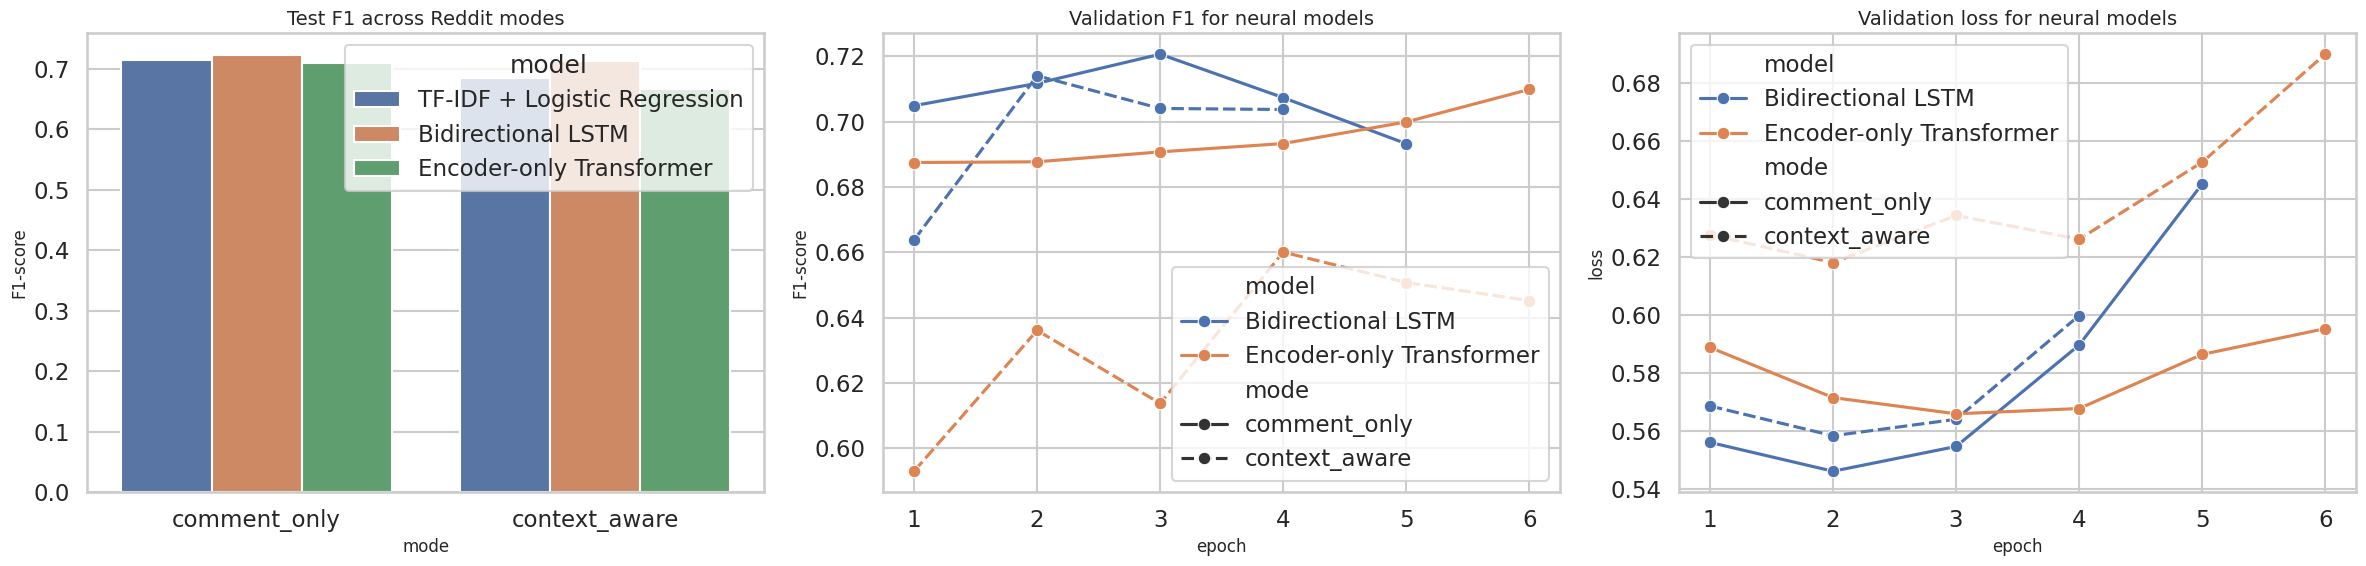

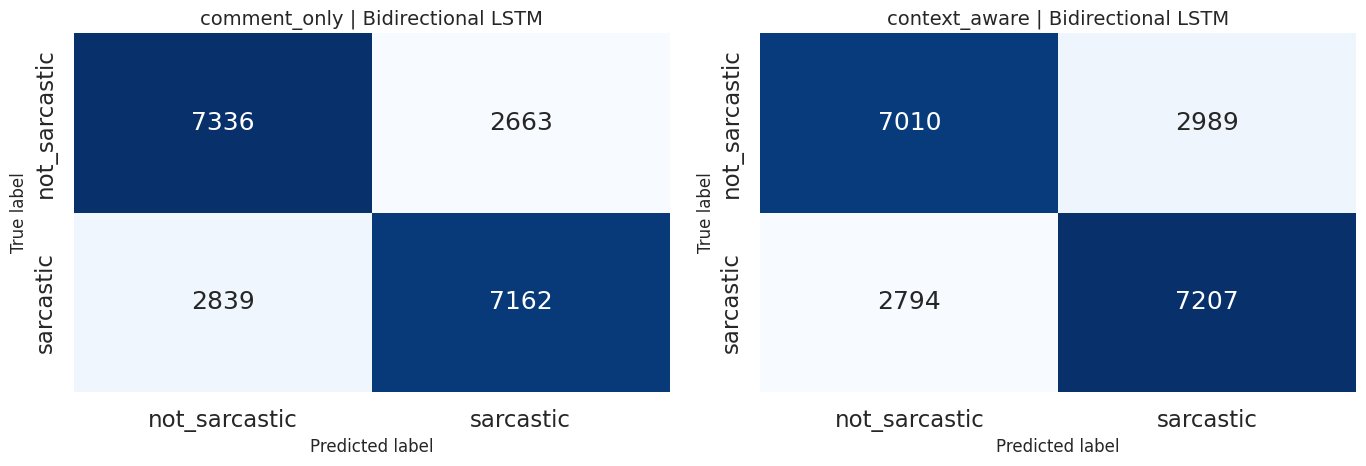

In [15]:
neural_history_df = pd.concat(
    [
        mode_artifacts[mode_name]["models"]["Bidirectional LSTM"]["history_df"]
        for mode_name in MODE_ORDER
    ]
    + [
        mode_artifacts[mode_name]["models"]["Encoder-only Transformer"]["history_df"]
        for mode_name in MODE_ORDER
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.barplot(
    data=test_comparison_df,
    x="mode",
    y="f1",
    hue="model",
    order=MODE_ORDER,
    hue_order=MODEL_ORDER,
    ax=axes[0],
)
axes[0].set_title("Test F1 across Reddit modes")
axes[0].set_ylabel("F1-score")
axes[0].set_xlabel("mode")
axes[0].tick_params(axis="x", rotation=0)

sns.lineplot(
    data=neural_history_df,
    x="epoch",
    y="val_f1",
    hue="model",
    style="mode",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Validation F1 for neural models")
axes[1].set_ylabel("F1-score")
axes[1].set_xlabel("epoch")

sns.lineplot(
    data=neural_history_df,
    x="epoch",
    y="val_loss",
    hue="model",
    style="mode",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Validation loss for neural models")
axes[2].set_ylabel("loss")
axes[2].set_xlabel("epoch")

plt.tight_layout()
plt.show()

best_models_by_mode = {}
fig, axes = plt.subplots(1, len(MODE_ORDER), figsize=(7 * len(MODE_ORDER), 5))
if len(MODE_ORDER) == 1:
    axes = [axes]

for ax, mode_name in zip(axes, MODE_ORDER):
    best_row = (
        test_comparison_df[test_comparison_df["mode"] == mode_name]
        .sort_values("f1", ascending=False)
        .iloc[0]
    )
    model_name = best_row["model"]
    best_models_by_mode[mode_name] = model_name
    test_frame = mode_artifacts[mode_name]["frames"]["test"]
    predictions = mode_artifacts[mode_name]["models"][model_name]["predictions"]["test"]
    show_confusion_matrix(
        test_frame["label"],
        predictions,
        title=f"{mode_name} | {model_name}",
        ax=ax,
    )

plt.tight_layout()
plt.show()


## 10. Error Analysis

The error analysis focuses on the strongest Reddit configuration, since that result is the most relevant evidence for the main benchmark discussion.


In [16]:
overall_best_row = test_comparison_df.sort_values("f1", ascending=False).iloc[0]
overall_best_mode = overall_best_row["mode"]
overall_best_model = overall_best_row["model"]

overall_best_test_frame = mode_artifacts[overall_best_mode]["frames"]["test"]
overall_best_predictions = mode_artifacts[overall_best_mode]["models"][overall_best_model]["predictions"]["test"]
overall_best_probabilities = mode_artifacts[overall_best_mode]["models"][overall_best_model]["probabilities"]["test"]

overall_best_error_df = collect_error_cases(
    overall_best_test_frame,
    overall_best_predictions,
    overall_best_probabilities,
    model_name=overall_best_model,
    mode_name=overall_best_mode,
    top_n=8,
)

display(
    overall_best_error_df[
        [
            "mode",
            "model",
            "error_type",
            "confidence",
            "label_name",
            "predicted_label_name",
            "subreddit",
            "score",
            "comment",
            "parent_comment",
            "model_text",
        ]
    ].sort_values(["error_type", "confidence"], ascending=[True, False])
)


,mode,model,error_type,confidence,label_name,predicted_label_name,subreddit,score,comment,parent_comment,model_text
8,comment_only,Bidirectional LSTM,false_negative,0.991424,sarcastic,not_sarcastic,WorldofTanks,2,"Indeed my friend, but this is an arcade MOBA, not War Thunder ;) imagine the brain power that would be required to take shell drop into account in our shots","I know it's not a glitch, hence why i used the word ""flaw"" in the title rather than ""bug"". The way it's supposed to be though is unintuitive and also not realistic (real tanks can easily adjust their aiming distance).","indeed my friend, but this is an arcade moba, not war thunder ;) imagine the brain power that would be required to take shell drop into account in our shots"
9,comment_only,Bidirectional LSTM,false_negative,0.982990,sarcastic,not_sarcastic,bayarea,2,"I was planning on cruising in the passing lane, but now that I read this on reddit I won't.","Please, everyone in the Bay Area.. if you are in front of the pack in the passing lane, then you are impeding traffic! No, people shouldn't have to pass us on the right. No, the passing lane is not the coasting lane....","i was planning on cruising in the passing lane, but now that i read this on reddit i won't."
10,comment_only,Bidirectional LSTM,false_negative,0.979690,sarcastic,not_sarcastic,lewronggeneration,-1,K,"I always find the use of that image- the Professor saying ""I don't want to live on this planet anymore,""- kind of ironic. The context of him saying it was that he, as a scientist and atheist staunchly opposed to the ...",k
11,comment_only,Bidirectional LSTM,false_negative,0.977231,sarcastic,not_sarcastic,gaming,1,"Oh yeah, I still love the game :) but when I see Artemis I'm like, ""Ahh fucking awesome, I LOVE ARTEMIS.""","LOL he is pretty crazy AD, remember its still in Beta so give em a chance to fix a few things before release.","oh yeah, i still love the game :) but when i see artemis i'm like, ""ahh fucking awesome, i love artemis."""
12,comment_only,Bidirectional LSTM,false_negative,0.976707,sarcastic,not_sarcastic,AskReddit,2,"I'm not a fan of the Cowboy's but calling them ""butthole surfers"" is pretty derogatory man.","On the positive side, Jimmy Johnson(former Cowboys coach) would come in and wave to us when he was buying tickets on Pan-Am and I got to meet the Butthole Surfers.","i'm not a fan of the cowboy's but calling them ""butthole surfers"" is pretty derogatory man."
13,comment_only,Bidirectional LSTM,false_negative,0.976542,sarcastic,not_sarcastic,fireemblem,0,I haven't finished PoR yet but I'm pretty sure Ike never gets Falchion or have I been playing a bootleg this whole time,"I might not have hit the deadline, but I finished my banner submission either way.",i haven't finished por yet but i'm pretty sure ike never gets falchion or have i been playing a bootleg this whole time
14,comment_only,Bidirectional LSTM,false_negative,0.976435,sarcastic,not_sarcastic,talesfromtechsupport,2,Same thing ... :P,New Zealand :),same thing ... :p
15,comment_only,Bidirectional LSTM,false_negative,0.974546,sarcastic,not_sarcastic,indieheads,2,Dang deantoni I love the music but you gotta find something else to film besides pretending to play midi controllers and drum machines while people dance interpretively around you.,Blood Orange - I Know,dang deantoni i love the music but you gotta find something else to film besides pretending to play midi controllers and drum machines while people dance interpretively around you.
0,comment_only,Bidirectional LSTM,false_positive,0.996815,not_sarcastic,sarcastic,nfl,18,yea i'm sure losing tom and bill won't hurt them at all,That's not what I mean,yea i'm sure losing tom and bill won't hurt them at all
1,comment_only,Bidirectional LSTM,false_positive,0.996619,not_sarcastic,sarcastic,The_Donald,2,Clearly racist,Milwaukee County Sheriff David Clarke requests mobilization of National Guard,clearly racist


## 11. Conclusions

The closing section summarizes:
- whether context improves performance
- how the neural models compare with TF-IDF on Reddit
- which Reddit configuration is the strongest benchmark result


In [22]:
tfidf_best_row = (
    test_comparison_df[test_comparison_df["model"] == "TF-IDF + Logistic Regression"]
    .sort_values("f1", ascending=False)
    .iloc[0]
)
best_neural_row = (
    test_comparison_df[test_comparison_df["model"] != "TF-IDF + Logistic Regression"]
    .sort_values("f1", ascending=False)
    .iloc[0]
)
context_delta_series = context_delta_df.set_index("model")["context_aware_minus_comment_only_f1"]

if (context_delta_series > 0.01).any():
    context_takeaway = (
        "Context helps at least one model by a non-trivial margin. The parent comment is therefore useful "
        "signal on Reddit, even if the gain is not uniform across all three architectures."
    )
elif (context_delta_series > 0).any():
    context_takeaway = (
        "Context gives only a marginal lift in this run. The report should mention the gain, but describe "
        "it as modest rather than transformational."
    )
else:
    context_takeaway = (
        "Context does not improve test F1 in this run. The report should say that the extra parent-comment "
        "signal was not enough to beat the simpler comment-only setup."
    )

if best_neural_row["f1"] > tfidf_best_row["f1"] + 0.01:
    model_takeaway = (
        f"The best neural model ({best_neural_row['model']}) clearly beats the best TF-IDF baseline "
        f"on Reddit by {best_neural_row['f1'] - tfidf_best_row['f1']:.4f} F1."
    )
elif best_neural_row["f1"] > tfidf_best_row["f1"]:
    model_takeaway = (
        f"A neural model ({best_neural_row['model']}) edges past TF-IDF, but only by "
        f"{best_neural_row['f1'] - tfidf_best_row['f1']:.4f} F1. The report should frame the gain as small."
    )
else:
    model_takeaway = (
        "TF-IDF remains competitive with the neural models on Reddit. The report should explicitly say that "
        "the simpler baseline stayed strong even on the harder benchmark."
    )

if overall_best_row["f1"] >= 0.75:
    recommendation = (
        "Yes. The best Reddit result is strong enough to anchor the main report result because it comes from "
        "the harder, less leakage-prone benchmark and still reaches a clearly usable performance level."
    )
else:
    recommendation = (
        "Use Reddit as the main benchmark anyway, but frame the result as challenging rather than solved. "
        "That gives the report a more honest final experiment and motivates pretrained encoders as the next extension."
    )

summary_markdown = dedent(
    f"""
    **Best overall Reddit result:** `{overall_best_model}` on `{overall_best_mode}` with test F1 = `{overall_best_row['f1']:.4f}`.

    **Does context help?** {context_takeaway}

    **Do BiLSTM or Transformer beat TF-IDF?** {model_takeaway}

    **Should Reddit become the main report benchmark?** {recommendation}
    """
)

display(Markdown(summary_markdown))

report_summary = {
    "best_mode": overall_best_mode,
    "best_model": overall_best_model,
    "best_test_f1": round(float(overall_best_row["f1"]), 4),
    "best_tfidf_mode": tfidf_best_row["mode"],
    "best_tfidf_test_f1": round(float(tfidf_best_row["f1"]), 4),
    "best_neural_model": best_neural_row["model"],
    "best_neural_mode": best_neural_row["mode"],
    "best_neural_test_f1": round(float(best_neural_row["f1"]), 4),
    "context_f1_delta_by_model": context_delta_series.round(4).to_dict(),
    "recommendation": recommendation,
}

report_summary



**Best overall Reddit result:** `Bidirectional LSTM` on `comment_only` with test F1 = `0.7225`.

**Does context help?** Context does not improve test F1 in this run. The report should say that the extra parent-comment signal was not enough to beat the simpler comment-only setup.

**Do BiLSTM or Transformer beat TF-IDF?** A neural model (Bidirectional LSTM) edges past TF-IDF, but only by 0.0072 F1. The report should frame the gain as small.

**Should Reddit become the main report benchmark?** Use Reddit as the main benchmark anyway, but frame the result as challenging rather than solved. That gives the report a more honest final experiment and motivates pretrained encoders as the next extension.


{'best_mode': 'comment_only',
 'best_model': 'Bidirectional LSTM',
 'best_test_f1': 0.7225,
 'best_tfidf_mode': 'comment_only',
 'best_tfidf_test_f1': 0.7153,
 'best_neural_model': 'Bidirectional LSTM',
 'best_neural_mode': 'comment_only',
 'best_neural_test_f1': 0.7225,
 'context_f1_delta_by_model': {'TF-IDF + Logistic Regression': -0.031,
  'Bidirectional LSTM': -0.0088,
  'Encoder-only Transformer': -0.0442},
 'recommendation': 'Use Reddit as the main benchmark anyway, but frame the result as challenging rather than solved. That gives the report a more honest final experiment and motivates pretrained encoders as the next extension.'}